# PGExplainer explanation for MCI classification on NNConv model

This notebook applies PGExplainer to the selected NNConv graph classifier. PGExplainer learns an edge mask for a prediction, so the interpretation focuses on the brain-region connections that most influenced the model output.


In [1]:
!pip install torch-geometric -q
!pip install networkx pandas -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.3 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from google.colab import drive
from torch_geometric.nn import global_mean_pool, global_max_pool, MessagePassing
from torch_geometric.explain import Explainer, PGExplainer


In [3]:
drive.mount('/content/drive')

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Mounted at /content/drive
Using device: cuda


### Model definition


In [4]:
class NNConvLayer(MessagePassing):
    def __init__(self, node_dim, edge_dim, out_dim):
        super().__init__(aggr='add')  # keep PyG's internal node_dim = -2

        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, node_dim * out_dim)
        )

        # Do NOT call this self.node_dim because PyG uses that internally
        self.in_channels = node_dim
        self.out_channels = out_dim

        self.gru = nn.GRUCell(out_dim, node_dim)

    def forward(self, x, edge_index, edge_attr):
        agg = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return self.gru(agg, x)

    def message(self, x_j, edge_attr):
        W = self.edge_mlp(edge_attr).view(
            -1,
            self.in_channels,
            self.out_channels
        )
        msg = torch.bmm(x_j.unsqueeze(1), W).squeeze(1)
        return msg

class NNConvNet(nn.Module):
    def __init__(self, node_in, edge_in, hidden, dropout):
        super().__init__()
        self.input_proj = nn.Linear(node_in, hidden)
        self.input_norm = nn.BatchNorm1d(hidden)
        self.conv1 = NNConvLayer(hidden, edge_in, hidden)
        self.norm1 = nn.BatchNorm1d(hidden)
        self.conv2 = NNConvLayer(hidden, edge_in, hidden)
        self.norm2 = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.input_proj(x)
        x = self.input_norm(x)
        x = x.relu()
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = x.relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = x.relu()
        x = self.dropout(x)
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)
        return self.classifier(x)


### Defining paths, feature names, and loading the selected model


In [5]:
MODEL_PATH = '/content/drive/MyDrive/team3_xai_gnn/nnconv_results/outer_checkpoints/cfg00_outer1.pt'
PREPROCESSED_DIR = '/content/drive/MyDrive/team3_xai_gnn/preprocessed'
TRAIN_PATH = os.path.join(PREPROCESSED_DIR, 'fold_1_train.pt')
VAL_PATH   = os.path.join(PREPROCESSED_DIR, 'fold_1_val.pt')
TEST_PATH  = os.path.join(PREPROCESSED_DIR, 'fold_1_test.pt')
DMRI_PATH  = '/content/drive/MyDrive/team3_xai_gnn/oasis3_graphmls_scale1'

NODE_FEATURE_NAMES = ['volume', 'thickness', 'has_volume', 'has_thickness']

model = NNConvNet(node_in=4, edge_in=15, hidden=32, dropout=0.3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print('NNConv model loaded.')


NNConv model loaded.


### Loading data and ROI labels


In [6]:
def load_graphs(path):
    if not os.path.exists(path):
        print(f'File not found: {path}')
        return []
    return torch.load(path, map_location=DEVICE, weights_only=False)

train_graphs = load_graphs(TRAIN_PATH)
val_graphs   = load_graphs(VAL_PATH)
test_graphs  = load_graphs(TEST_PATH)

if len(test_graphs) == 0:
    raise RuntimeError('No test graphs found. Check TEST_PATH.')

pg_train_graphs = train_graphs if len(train_graphs) > 0 else test_graphs
sample_graph = test_graphs[0]

print(f'Train subjects: {len(train_graphs)}')
print(f'Val subjects:   {len(val_graphs)}')
print(f'Test subjects:  {len(test_graphs)}')
print('Sample x shape:', tuple(sample_graph.x.shape))
print('Sample edge_index shape:', tuple(sample_graph.edge_index.shape))
print('Sample edge_attr shape:', tuple(sample_graph.edge_attr.shape) if sample_graph.edge_attr is not None else None)

# ROI names from the GraphML files.
graphml_files = [f for f in os.listdir(DMRI_PATH) if f.endswith('.graphml')]
if len(graphml_files) == 0:
    node_labels = {i: f'Node {i}' for i in range(sample_graph.x.size(0))}
    print('No GraphML files found. Falling back to generic node labels.')
else:
    sample_G = nx.read_graphml(os.path.join(DMRI_PATH, graphml_files[0]))
    sample_G.remove_edges_from(list(nx.selfloop_edges(sample_G)))
    nodes = list(sample_G.nodes(data=True))
    node_labels = {i: attrs.get('dn_name', f'node_{i}').strip() for i, (_, attrs) in enumerate(nodes)}
    print(f'Node label map built: {len(node_labels)} ROIs')

EDGE_FEATURE_NAMES = [f'Edge feature {i}' for i in range(sample_graph.edge_attr.size(-1))]


Train subjects: 431
Val subjects:   77
Test subjects:  127
Sample x shape: (124, 4)
Sample edge_index shape: (2, 6380)
Sample edge_attr shape: (6380, 15)
Node label map built: 124 ROIs


### Helper functions


In [7]:
CLASS_NAMES = {0: 'CN', 1: 'MCI'}

def node_label(idx):
    return node_labels.get(int(idx), f'Node {int(idx)}')

def edge_feature_label(idx):
    return EDGE_FEATURE_NAMES[int(idx)] if int(idx) < len(EDGE_FEATURE_NAMES) else f'Edge feature {int(idx)}'

def make_batch(g):
    return torch.zeros(g.x.size(0), dtype=torch.long, device=DEVICE)

def get_prediction(g):
    g = g.to(DEVICE)
    batch = make_batch(g)
    with torch.no_grad():
        logits = model(g.x, g.edge_index, g.edge_attr, batch)
        probs = torch.softmax(logits, dim=-1)
        pred = int(logits.argmax(dim=-1).item())
    return pred, float(probs[0, 0].item()), float(probs[0, 1].item())

def classify_test_subjects(test_graphs):
    rows = []
    for idx, g in enumerate(test_graphs):
        pred, prob_cn, prob_mci = get_prediction(g)
        true = int(g.y.item()) if hasattr(g, 'y') and g.y is not None else None
        subject_id = getattr(g, 'subject_id', f'test_index_{idx}')
        rows.append({
            'test_index': idx,
            'subject_id': subject_id,
            'true_label': true,
            'pred_label': pred,
            'prob_CN': prob_cn,
            'prob_MCI': prob_mci,
            'outcome': ('TP' if true == 1 and pred == 1 else
                        'TN' if true == 0 and pred == 0 else
                        'FP' if true == 0 and pred == 1 else
                        'FN' if true == 1 and pred == 0 else 'NA')
        })
    return pd.DataFrame(rows)

predictions_df = classify_test_subjects(test_graphs)
display(predictions_df.head())
print(predictions_df['outcome'].value_counts(dropna=False))


,test_index,subject_id,true_label,pred_label,prob_CN,prob_MCI,outcome
0,0,OAS30002,0,0,0.647086,0.352914,TN
1,1,OAS30008,0,0,0.709212,0.290787,TN
2,2,OAS30017,0,0,0.660747,0.339253,TN
3,3,OAS30030,0,0,0.606893,0.393107,TN
4,4,OAS30032,0,0,0.675117,0.324883,TN


outcome
TN    87
FP    18
TP    14
FN     8
Name: count, dtype: int64


### Prediction outcome groups

The test subjects are grouped into TP, TN, FP, and FN outcomes. For each available outcome, the notebook selects the most confident subject for detailed visualization, then later computes population-level PGExplainer summaries across all subjects in that outcome group.

In [8]:
# Build outcome groups using the same confidence rule for all explanation sections.
outcome_pools = {}
case_rows = []

for tag in ['TP', 'TN', 'FP', 'FN']:
    subset = predictions_df[predictions_df['outcome'] == tag].copy()

    if subset.empty:
        print(f'{tag}: no subjects available.')
        outcome_pools[tag] = subset
        continue

    # TP/FP: strongest positive prediction. TN/FN: strongest negative prediction.
    if tag in ['TP', 'FP']:
        subset = subset.sort_values('prob_MCI', ascending=False)
    else:
        subset = subset.sort_values('prob_MCI', ascending=True)

    outcome_pools[tag] = subset
    case_rows.append(subset.iloc[0])

case_summary_df = pd.DataFrame(case_rows).reset_index(drop=True)

print('Outcome counts:')
display(predictions_df['outcome'].value_counts(dropna=False).rename_axis('outcome').reset_index(name='n_subjects'))

print('Most confident representative subjects:')
display(case_summary_df)

Outcome counts:


,outcome,n_subjects
0,TN,87
1,FP,18
2,TP,14
3,FN,8


Most confident representative subjects:


,test_index,subject_id,true_label,pred_label,prob_CN,prob_MCI,outcome
0,109,OAS31004,1,1,0.302832,0.697168,TP
1,76,OAS30723,0,0,0.720792,0.279208,TN
2,48,OAS30443,0,1,0.211227,0.788773,FP
3,114,OAS31050,1,0,0.633779,0.366221,FN


### Configure PGExplainer


In [9]:
pg_epochs = 30
pg_lr = 0.003

pg_explainer = Explainer(
    model=model,
    algorithm=PGExplainer(epochs=pg_epochs, lr=pg_lr),
    explanation_type='phenomenon',
    node_mask_type=None,
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw',
    ),
)
pg_explainer.algorithm = pg_explainer.algorithm.to(DEVICE)
print('PGExplainer configured.')


PGExplainer configured.


### Train PGExplainer

The NNConv model remains frozen. Only the explanation network is trained. The target used for each graph is the model prediction, so the explanation describes what the model used for its own decision.


In [10]:
model.eval()
max_pg_train_graphs = min(80, len(pg_train_graphs))
pg_train_subset = pg_train_graphs[:max_pg_train_graphs]

if len(pg_train_subset) == 0:
    raise RuntimeError('No graphs available for PGExplainer training.')

for epoch in range(pg_epochs):
    total_loss = 0.0
    for g_pg in pg_train_subset:
        g_pg = g_pg.to(DEVICE)
        batch_pg = make_batch(g_pg)
        with torch.no_grad():
            logits_pg = model(g_pg.x, g_pg.edge_index, g_pg.edge_attr, batch_pg)
            target_pg = logits_pg.argmax(dim=-1)
        loss = pg_explainer.algorithm.train(
            epoch,
            model,
            g_pg.x,
            g_pg.edge_index,
            target=target_pg,
            edge_attr=g_pg.edge_attr,
            batch=batch_pg,
        )
        total_loss += float(loss)
    print(f'Epoch {epoch + 1:02d}/{pg_epochs} | PGExplainer loss: {total_loss / len(pg_train_subset):.4f}')


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/explain/algorithm/pg_explainer.py:224: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss)


Epoch 01/30 | PGExplainer loss: 44.1280
Epoch 02/30 | PGExplainer loss: 1.4911
Epoch 03/30 | PGExplainer loss: 0.9091
Epoch 04/30 | PGExplainer loss: 0.7840
Epoch 05/30 | PGExplainer loss: 0.7427
Epoch 06/30 | PGExplainer loss: 0.7243
Epoch 07/30 | PGExplainer loss: 0.7144
Epoch 08/30 | PGExplainer loss: 0.7088
Epoch 09/30 | PGExplainer loss: 0.7053
Epoch 10/30 | PGExplainer loss: 0.7031
Epoch 11/30 | PGExplainer loss: 0.7013
Epoch 12/30 | PGExplainer loss: 0.7004
Epoch 13/30 | PGExplainer loss: 0.6994
Epoch 14/30 | PGExplainer loss: 0.6989
Epoch 15/30 | PGExplainer loss: 0.6984
Epoch 16/30 | PGExplainer loss: 0.6982
Epoch 17/30 | PGExplainer loss: 0.6979
Epoch 18/30 | PGExplainer loss: 0.6977
Epoch 19/30 | PGExplainer loss: 0.6976
Epoch 20/30 | PGExplainer loss: 0.6975
Epoch 21/30 | PGExplainer loss: 0.6974
Epoch 22/30 | PGExplainer loss: 0.6973
Epoch 23/30 | PGExplainer loss: 0.6973
Epoch 24/30 | PGExplainer loss: 0.6972
Epoch 25/30 | PGExplainer loss: 0.6972
Epoch 26/30 | PGExplaine

### PGExplainer functions

In [11]:
def explain_with_pgexplainer(g):
    g = g.to(DEVICE)
    batch = make_batch(g)
    pred, prob_cn, prob_mci = get_prediction(g)

    explanation = pg_explainer(
        x=g.x,
        edge_index=g.edge_index,
        edge_attr=g.edge_attr,
        batch=batch,
        target=torch.tensor([pred], device=DEVICE),
    )

    edge_mask = explanation.edge_mask.detach().cpu().numpy()
    return edge_mask, pred, prob_cn, prob_mci


def build_pg_connection_table(g, edge_mask, top_k=15, merge_reverse_edges=True):
    edge_index_cpu = g.edge_index.detach().cpu()
    rows = []

    if merge_reverse_edges:
        connection_scores = {}

        for edge_pos, score in enumerate(edge_mask):
            src = int(edge_index_cpu[0, edge_pos].item())
            dst = int(edge_index_cpu[1, edge_pos].item())
            key = tuple(sorted((src, dst)))

            if key not in connection_scores:
                connection_scores[key] = {
                    'source_node': key[0],
                    'target_node': key[1],
                    'edge_positions': [],
                    'directed_edges': [],
                    'scores': [],
                }

            connection_scores[key]['edge_positions'].append(int(edge_pos))
            connection_scores[key]['directed_edges'].append(f'{src}->{dst}')
            connection_scores[key]['scores'].append(float(score))

        for item in connection_scores.values():
            scores = np.array(item['scores'])

            rows.append({
                'source_region': node_label(item['source_node']),
                'target_region': node_label(item['target_node']),
                'source_node': item['source_node'],
                'target_node': item['target_node'],
                'pg_score_max': float(scores.max()),
                'pg_score_mean': float(scores.mean()),
                'edge_positions': item['edge_positions'],
                'directed_edges_in_edge_index': item['directed_edges'],
            })

        df = pd.DataFrame(rows).sort_values('pg_score_max', ascending=False).reset_index(drop=True)

        if top_k is not None:
            df = df.head(top_k).reset_index(drop=True)

        df.insert(0, 'rank', np.arange(1, len(df) + 1))
        return df

    order = np.argsort(edge_mask)[::-1]
    if top_k is not None:
        order = order[:top_k]

    for rank, edge_pos in enumerate(order, start=1):
        src = int(edge_index_cpu[0, edge_pos].item())
        dst = int(edge_index_cpu[1, edge_pos].item())

        rows.append({
            'rank': rank,
            'source_region': node_label(src),
            'target_region': node_label(dst),
            'source_node': src,
            'target_node': dst,
            'edge_position': int(edge_pos),
            'directed_edge': f'{src}->{dst}',
            'pg_score': float(edge_mask[edge_pos]),
        })

    return pd.DataFrame(rows)


def visualize_pg_connections_from_table(connection_df, top_k=12, score_column='pg_score_max', title=None):
    plot_df = connection_df.head(top_k).copy()

    if plot_df.empty:
        print('No connections to visualize.')
        return

    G = nx.Graph()

    for _, row in plot_df.iterrows():
        src_label = row['source_region']
        dst_label = row['target_region']
        score = float(row[score_column])
        G.add_edge(src_label, dst_label, weight=score, label=f'{score:.3f}')

    plt.figure(figsize=(13, 9))
    pos = nx.spring_layout(G, k=1.6, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=1300, edgecolors='black')

    weights_raw = np.array([G[u][v]['weight'] for u, v in G.edges()])
    if len(weights_raw) > 0 and weights_raw.max() > weights_raw.min():
        widths = 1.5 + 6.0 * (weights_raw - weights_raw.min()) / (weights_raw.max() - weights_raw.min())
    else:
        widths = np.ones(len(weights_raw)) * 3.0

    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.75)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'label'), font_size=8)
    plt.title(title or f'PGExplainer: Top {top_k} brain-region connections', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def build_node_importance_from_connections(connection_df):
    # Convert connection scores into a node-level summary by averaging incident edge importance.
    rows = []

    for _, row in connection_df.iterrows():
        for side in ['source', 'target']:
            rows.append({
                'node': int(row[f'{side}_node']),
                'region': row[f'{side}_region'],
                'pg_score_max': float(row['pg_score_max']),
                'pg_score_mean': float(row['pg_score_mean']),
            })

    if not rows:
        return pd.DataFrame(columns=['node', 'region', 'mean_incident_pg_score', 'max_incident_pg_score', 'n_incident_connections'])

    return (
        pd.DataFrame(rows)
        .groupby(['node', 'region'], as_index=False)
        .agg(
            mean_incident_pg_score=('pg_score_max', 'mean'),
            max_incident_pg_score=('pg_score_max', 'max'),
            n_incident_connections=('pg_score_max', 'count'),
        )
        .sort_values('mean_incident_pg_score', ascending=False)
        .reset_index(drop=True)
    )

OUTCOME_COLORS = {
    'TP': '#d62728',
    'TN': '#1f77b4',
    'FP': '#ff7f0e',
    'FN': '#9467bd',
}


def _connection_label(row):
    return f"{row['source_region']} -- {row['target_region']}"


def plot_top_pg_connections_bar(connection_df, title, top_k=10, score_column='pg_score_max', color='#4c72b0'):
    plot_df = connection_df.head(top_k).copy()

    if plot_df.empty:
        print('No connections to plot.')
        return

    plot_df['connection'] = plot_df.apply(_connection_label, axis=1)
    plot_df = plot_df.iloc[::-1]

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(plot_df['connection'], plot_df[score_column], color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('PGExplainer edge-mask score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

    max_score = float(plot_df[score_column].max()) if len(plot_df) else 0.0
    offset = max(max_score * 0.01, 1e-4)
    for bar, score in zip(bars, plot_df[score_column]):
        ax.text(bar.get_width() + offset,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_top_pg_nodes_bar(node_df, title, top_k=10, score_column='mean_incident_pg_score', color='#4c72b0'):
    plot_df = node_df.head(top_k).copy()

    if plot_df.empty:
        print('No nodes to plot.')
        return

    plot_df = plot_df.iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(plot_df['region'], plot_df[score_column], color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Mean incident PGExplainer score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

    max_score = float(plot_df[score_column].max()) if len(plot_df) else 0.0
    offset = max(max_score * 0.01, 1e-4)
    for bar, score in zip(bars, plot_df[score_column]):
        ax.text(bar.get_width() + offset,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_pg_score_distribution(connection_df, title, score_column='pg_score_max', color='#4c72b0'):
    if connection_df.empty:
        print('No scores to plot.')
        return

    scores = connection_df[score_column].dropna().astype(float)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(scores, bins=20, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('PGExplainer edge-mask score', fontsize=11)
    ax.set_ylabel('Number of connections', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(scores.mean(), linewidth=1.2, linestyle='--', color='black')
    ax.text(0.98, 0.95,
            f'n={len(scores)}\nmean={scores.mean():.4f}\nmax={scores.max():.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.75))

    plt.tight_layout()
    plt.show()


def plot_case_pg_summary_panels(tag, connection_df, node_df, subject_id=None, top_k=10):
    color = OUTCOME_COLORS.get(tag, '#4c72b0')
    title_prefix = f'{tag}' if subject_id is None else f'{tag} | {subject_id}'

    plot_top_pg_connections_bar(
        connection_df,
        title=f'{title_prefix}\nTop {top_k} connections by PGExplainer',
        top_k=top_k,
        score_column='pg_score_max',
        color=color,
    )

    plot_top_pg_nodes_bar(
        node_df,
        title=f'{title_prefix}\nTop {top_k} regions by incident PGExplainer score',
        top_k=top_k,
        score_column='mean_incident_pg_score',
        color=color,
    )

    plot_pg_score_distribution(
        connection_df,
        title=f'{title_prefix}\nDistribution of PGExplainer connection scores',
        score_column='pg_score_max',
        color=color,
    )


def plot_population_pg_connections_by_outcome(summary_df, top_k=10):
    if summary_df.empty:
        print('No population connection summary to plot.')
        return

    available_tags = [tag for tag in ['TP', 'TN', 'FP', 'FN'] if tag in summary_df['outcome'].unique()]
    if not available_tags:
        print('No available outcome groups to plot.')
        return

    fig, axes = plt.subplots(1, len(available_tags), figsize=(6 * len(available_tags), 6))
    if len(available_tags) == 1:
        axes = [axes]

    for ax, tag in zip(axes, available_tags):
        plot_df = summary_df[summary_df['outcome'] == tag].head(top_k).copy()
        plot_df['connection'] = plot_df.apply(_connection_label, axis=1)
        plot_df = plot_df.iloc[::-1]
        color = OUTCOME_COLORS.get(tag, '#4c72b0')

        ax.barh(plot_df['connection'], plot_df['mean_pg_score_max'], color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax.set_xlabel('Mean PGExplainer score')
        ax.set_title(f'{tag}\nTop population connections', fontsize=12, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle('Population-averaged PGExplainer connections by outcome', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_population_pg_nodes_by_outcome(summary_df, top_k=10):
    if summary_df.empty:
        print('No population node summary to plot.')
        return

    available_tags = [tag for tag in ['TP', 'TN', 'FP', 'FN'] if tag in summary_df['outcome'].unique()]
    if not available_tags:
        print('No available outcome groups to plot.')
        return

    fig, axes = plt.subplots(1, len(available_tags), figsize=(6 * len(available_tags), 6))
    if len(available_tags) == 1:
        axes = [axes]

    for ax, tag in zip(axes, available_tags):
        plot_df = summary_df[summary_df['outcome'] == tag].head(top_k).copy().iloc[::-1]
        color = OUTCOME_COLORS.get(tag, '#4c72b0')

        ax.barh(plot_df['region'], plot_df['mean_incident_pg_score'], color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax.set_xlabel('Mean incident PGExplainer score')
        ax.set_title(f'{tag}\nTop population regions', fontsize=12, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle('Population-averaged PGExplainer regions by outcome', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


### Representative TP, TN, FP, and FN explanations

For each available outcome group, the most confident subject is explained with PGExplainer. The notebook displays tables, bar plots, score histograms, and a small connection graph so the explanation is easier to read visually.

In [12]:
case_pg_tables = {}
case_node_tables = {}
case_pg_summary_rows = []

for _, row in case_summary_df.iterrows():
    tag = row['outcome']
    idx = int(row['test_index'])
    subject_id = row['subject_id']
    g = test_graphs[idx].to(DEVICE)

    edge_mask_case, pred, prob_cn, prob_mci = explain_with_pgexplainer(g)
    connection_table = build_pg_connection_table(g, edge_mask_case, top_k=15, merge_reverse_edges=True)
    node_table = build_node_importance_from_connections(connection_table)

    case_pg_tables[tag] = connection_table
    case_node_tables[tag] = node_table

    top_connection = connection_table.iloc[0] if not connection_table.empty else None

    case_pg_summary_rows.append({
        'outcome': tag,
        'subject_id': subject_id,
        'test_index': idx,
        'true_label': CLASS_NAMES.get(int(row['true_label']), row['true_label']),
        'pred_label': CLASS_NAMES[int(row['pred_label'])],
        'prob_MCI': float(row['prob_MCI']),
        'top_connection': (
            f"{top_connection['source_region']} -- {top_connection['target_region']}"
            if top_connection is not None else None
        ),
        'top_pg_score': float(top_connection['pg_score_max']) if top_connection is not None else np.nan,
    })

pg_case_summary_df = pd.DataFrame(case_pg_summary_rows)

display(pg_case_summary_df)

for tag, table in case_pg_tables.items():
    subject_id = pg_case_summary_df.loc[pg_case_summary_df['outcome'] == tag, 'subject_id'].iloc[0]

    print(f'\n{tag}: top PGExplainer connections')
    display(table.head(10))

    print(f'\n{tag}: top PGExplainer regions')
    display(case_node_tables[tag].head(10))

    plot_case_pg_summary_panels(
        tag,
        table,
        case_node_tables[tag],
        subject_id=subject_id,
        top_k=10,
    )

    visualize_pg_connections_from_table(
        table,
        top_k=12,
        score_column='pg_score_max',
        title=f'PGExplainer {tag}: top brain-region connections',
    )


Output hidden; open in https://colab.research.google.com to view.

### Population-level PGExplainer summaries by outcome

The trained PGExplainer is applied to every subject in each available outcome group. Connection scores are averaged within each group, then shown as tables and outcome-level bar plots.

Running population PGExplainer for TP subjects: n=14
Running population PGExplainer for TN subjects: n=87
Running population PGExplainer for FP subjects: n=18
Running population PGExplainer for FN subjects: n=8
Population connection summary:


,outcome,source_node,target_node,source_region,target_region,mean_pg_score_max,std_pg_score_max,mean_pg_score_mean,n_subjects
0,FN,33,35,Right-Amygdala,ctx-lh-parsorbitalis,3.786142e-05,9.274116e-05,3.706147e-05,6
1,FN,13,105,ctx-rh-caudalanteriorcingulate,Left-Hippocampus_Hippocampal_fissure,8.597590e-06,1.215883e-05,5.463368e-06,2
2,FN,35,84,ctx-lh-parsorbitalis,Left-Medio_Dorsal,6.778543e-06,1.174078e-05,5.317018e-06,3
3,FN,33,84,Right-Amygdala,Left-Medio_Dorsal,1.742233e-06,2.463890e-06,1.692504e-06,2
4,FN,82,84,ctx-rh-lateraloccipital,Left-Medio_Dorsal,7.835202e-07,1.218213e-06,5.438768e-07,6
5,FN,31,82,Right-Medio_Dorsal,ctx-rh-lateraloccipital,3.367123e-07,6.734247e-07,2.754948e-07,4
6,FN,25,35,Brain_Stem-Medulla,ctx-lh-parsorbitalis,2.213337e-07,4.949172e-07,1.822000e-07,5
7,FN,26,105,Brain_Stem-Pons,Left-Hippocampus_Hippocampal_fissure,1.326495e-07,1.875947e-07,9.067933e-08,2
8,FN,25,82,Brain_Stem-Medulla,ctx-rh-lateraloccipital,5.350137e-08,9.266709e-08,3.515131e-08,3
9,FN,42,105,ctx-lh-parstriangularis,Left-Hippocampus_Hippocampal_fissure,4.571513e-08,7.918092e-08,2.627861e-08,3


Population node summary:


,outcome,node,region,mean_incident_pg_score,max_incident_pg_score,n_subjects
0,FN,35,ctx-lh-parsorbitalis,1.035909e-06,2.271685e-04,8
1,FN,33,Right-Amygdala,8.486174e-07,2.271685e-04,8
2,FN,105,Left-Hippocampus_Hippocampal_fissure,2.199711e-07,1.719518e-05,8
3,FN,84,Left-Medio_Dorsal,6.147229e-08,2.033563e-05,8
4,FN,13,ctx-rh-caudalanteriorcingulate,3.582329e-08,1.719518e-05,8
5,FN,82,ctx-rh-lateraloccipital,1.601875e-08,2.513914e-06,8
6,FN,31,Right-Medio_Dorsal,2.865925e-09,1.346849e-06,8
7,FN,25,Brain_Stem-Medulla,2.612847e-09,1.106669e-06,8
8,FN,26,Brain_Stem-Pons,3.768459e-10,2.652989e-07,8
9,FN,36,ctx-rh-caudalmiddlefrontal,3.614683e-10,8.524448e-08,8


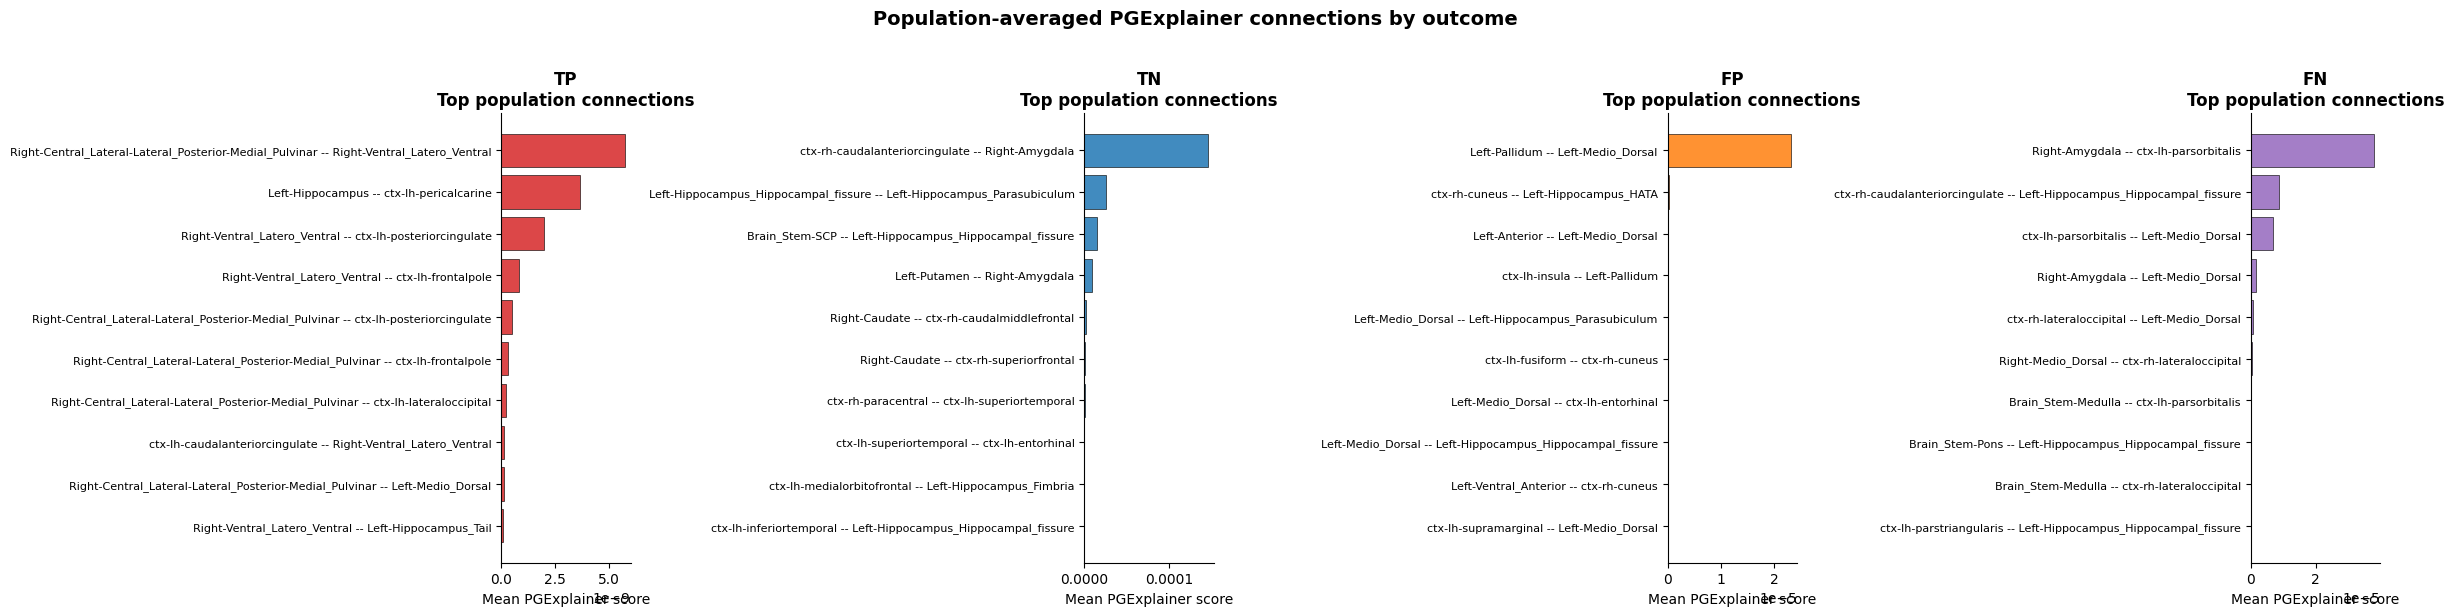

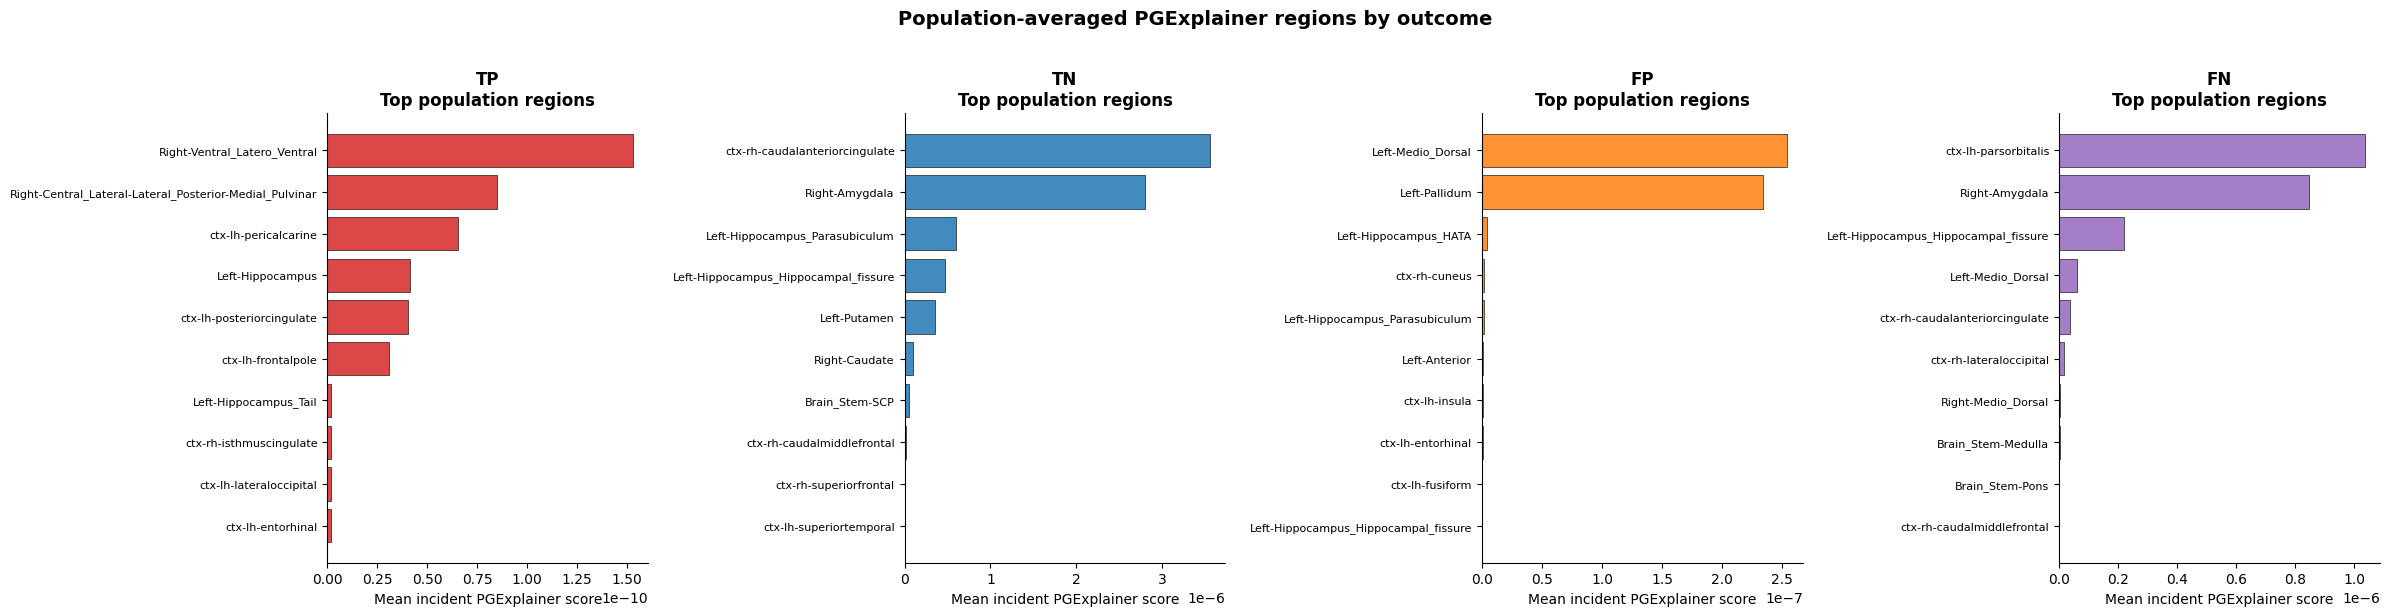

In [13]:
def run_pg_population_for_outcome(outcome_df, tag, top_k_per_subject=None):
    connection_tables = []
    node_tables = []
    failures = []

    for _, row in outcome_df.iterrows():
        idx = int(row['test_index'])
        subject_id = row['subject_id']
        g = test_graphs[idx].to(DEVICE)

        try:
            edge_mask, pred, prob_cn, prob_mci = explain_with_pgexplainer(g)
            connection_table = build_pg_connection_table(
                g,
                edge_mask,
                top_k=top_k_per_subject,
                merge_reverse_edges=True,
            )

            connection_table['subject_id'] = subject_id
            connection_table['test_index'] = idx
            connection_table['outcome'] = tag
            connection_table['true_label'] = row['true_label']
            connection_table['pred_label'] = row['pred_label']
            connection_table['prob_MCI'] = row['prob_MCI']

            node_table = build_node_importance_from_connections(connection_table)
            node_table['subject_id'] = subject_id
            node_table['test_index'] = idx
            node_table['outcome'] = tag
            node_table['true_label'] = row['true_label']
            node_table['pred_label'] = row['pred_label']
            node_table['prob_MCI'] = row['prob_MCI']

            connection_tables.append(connection_table)
            node_tables.append(node_table)

        except Exception as e:
            failures.append((subject_id, idx, str(e)))
            print(f'{tag} | subject {subject_id} | test_index {idx} failed: {e}')

    return {
        'connections': pd.concat(connection_tables, ignore_index=True) if connection_tables else pd.DataFrame(),
        'nodes': pd.concat(node_tables, ignore_index=True) if node_tables else pd.DataFrame(),
        'failures': failures,
    }


def summarize_population_connections(connection_df):
    if connection_df.empty:
        return pd.DataFrame()

    return (
        connection_df
        .groupby(['outcome', 'source_node', 'target_node', 'source_region', 'target_region'], as_index=False)
        .agg(
            mean_pg_score_max=('pg_score_max', 'mean'),
            std_pg_score_max=('pg_score_max', 'std'),
            mean_pg_score_mean=('pg_score_mean', 'mean'),
            n_subjects=('subject_id', 'nunique'),
        )
        .sort_values(['outcome', 'mean_pg_score_max'], ascending=[True, False])
        .reset_index(drop=True)
    )


def summarize_population_nodes(node_df):
    if node_df.empty:
        return pd.DataFrame()

    return (
        node_df
        .groupby(['outcome', 'node', 'region'], as_index=False)
        .agg(
            mean_incident_pg_score=('mean_incident_pg_score', 'mean'),
            max_incident_pg_score=('max_incident_pg_score', 'max'),
            n_subjects=('subject_id', 'nunique'),
        )
        .sort_values(['outcome', 'mean_incident_pg_score'], ascending=[True, False])
        .reset_index(drop=True)
    )


pg_population_results = {}

for tag in ['TP', 'TN', 'FP', 'FN']:
    outcome_df = outcome_pools.get(tag, pd.DataFrame())

    if outcome_df.empty:
        print(f'{tag}: no subjects, skipping population PGExplainer summary.')
        continue

    print(f'Running population PGExplainer for {tag} subjects: n={len(outcome_df)}')
    pg_population_results[tag] = run_pg_population_for_outcome(
        outcome_df,
        tag,
        top_k_per_subject=None,  # keep all connections before averaging
    )

all_population_connections = pd.concat(
    [result['connections'] for result in pg_population_results.values() if not result['connections'].empty],
    ignore_index=True
) if pg_population_results else pd.DataFrame()

all_population_nodes = pd.concat(
    [result['nodes'] for result in pg_population_results.values() if not result['nodes'].empty],
    ignore_index=True
) if pg_population_results else pd.DataFrame()

pg_population_connection_summary_df = summarize_population_connections(all_population_connections)
pg_population_node_summary_df = summarize_population_nodes(all_population_nodes)

print('Population connection summary:')
display(pg_population_connection_summary_df.groupby('outcome').head(10))

print('Population node summary:')
display(pg_population_node_summary_df.groupby('outcome').head(10))

plot_population_pg_connections_by_outcome(pg_population_connection_summary_df, top_k=10)
plot_population_pg_nodes_by_outcome(pg_population_node_summary_df, top_k=10)


### Final interpretation tables

In [14]:
print('Prediction outcome counts:')
display(predictions_df['outcome'].value_counts(dropna=False).rename_axis('outcome').reset_index(name='n_subjects'))

print('Representative subject summary:')
display(case_summary_df)

print('Representative PGExplainer summary by outcome:')
display(pg_case_summary_df)

print('Top population-level connections by outcome:')
display(pg_population_connection_summary_df.groupby('outcome').head(10))

print('Top population-level nodes by outcome:')
display(pg_population_node_summary_df.groupby('outcome').head(10))

Prediction outcome counts:


,outcome,n_subjects
0,TN,87
1,FP,18
2,TP,14
3,FN,8


Representative subject summary:


,test_index,subject_id,true_label,pred_label,prob_CN,prob_MCI,outcome
0,109,OAS31004,1,1,0.302832,0.697168,TP
1,76,OAS30723,0,0,0.720792,0.279208,TN
2,48,OAS30443,0,1,0.211227,0.788773,FP
3,114,OAS31050,1,0,0.633779,0.366221,FN


Representative PGExplainer summary by outcome:


,outcome,subject_id,test_index,true_label,pred_label,prob_MCI,top_connection,top_pg_score
0,TP,OAS31004,109,MCI,MCI,0.697168,Left-Hippocampus -- ctx-lh-pericalcarine,3.655852e-08
1,TN,OAS30723,76,CN,CN,0.279208,Right-Medio_Dorsal -- ctx-lh-posteriorcingulate,2.195350e-10
2,FP,OAS30443,48,CN,MCI,0.788773,ctx-rh-cuneus -- Left-Hippocampus_HATA,1.102023e-06
3,FN,OAS31050,114,MCI,CN,0.366221,ctx-rh-fusiform -- ctx-lh-parstriangularis,3.582747e-13


Top population-level connections by outcome:


,outcome,source_node,target_node,source_region,target_region,mean_pg_score_max,std_pg_score_max,mean_pg_score_mean,n_subjects
0,FN,33,35,Right-Amygdala,ctx-lh-parsorbitalis,3.786142e-05,9.274116e-05,3.706147e-05,6
1,FN,13,105,ctx-rh-caudalanteriorcingulate,Left-Hippocampus_Hippocampal_fissure,8.597590e-06,1.215883e-05,5.463368e-06,2
2,FN,35,84,ctx-lh-parsorbitalis,Left-Medio_Dorsal,6.778543e-06,1.174078e-05,5.317018e-06,3
3,FN,33,84,Right-Amygdala,Left-Medio_Dorsal,1.742233e-06,2.463890e-06,1.692504e-06,2
4,FN,82,84,ctx-rh-lateraloccipital,Left-Medio_Dorsal,7.835202e-07,1.218213e-06,5.438768e-07,6
5,FN,31,82,Right-Medio_Dorsal,ctx-rh-lateraloccipital,3.367123e-07,6.734247e-07,2.754948e-07,4
6,FN,25,35,Brain_Stem-Medulla,ctx-lh-parsorbitalis,2.213337e-07,4.949172e-07,1.822000e-07,5
7,FN,26,105,Brain_Stem-Pons,Left-Hippocampus_Hippocampal_fissure,1.326495e-07,1.875947e-07,9.067933e-08,2
8,FN,25,82,Brain_Stem-Medulla,ctx-rh-lateraloccipital,5.350137e-08,9.266709e-08,3.515131e-08,3
9,FN,42,105,ctx-lh-parstriangularis,Left-Hippocampus_Hippocampal_fissure,4.571513e-08,7.918092e-08,2.627861e-08,3


Top population-level nodes by outcome:


,outcome,node,region,mean_incident_pg_score,max_incident_pg_score,n_subjects
0,FN,35,ctx-lh-parsorbitalis,1.035909e-06,2.271685e-04,8
1,FN,33,Right-Amygdala,8.486174e-07,2.271685e-04,8
2,FN,105,Left-Hippocampus_Hippocampal_fissure,2.199711e-07,1.719518e-05,8
3,FN,84,Left-Medio_Dorsal,6.147229e-08,2.033563e-05,8
4,FN,13,ctx-rh-caudalanteriorcingulate,3.582329e-08,1.719518e-05,8
5,FN,82,ctx-rh-lateraloccipital,1.601875e-08,2.513914e-06,8
6,FN,31,Right-Medio_Dorsal,2.865925e-09,1.346849e-06,8
7,FN,25,Brain_Stem-Medulla,2.612847e-09,1.106669e-06,8
8,FN,26,Brain_Stem-Pons,3.768459e-10,2.652989e-07,8
9,FN,36,ctx-rh-caudalmiddlefrontal,3.614683e-10,8.524448e-08,8


###Per class analysis

In [15]:
# Per-class PGExplainer population analysis


# Choose class grouping:
#   'true_label' = group by ground-truth CN/MCI
#   'pred_label' = group by model-predicted CN/MCI
CLASS_GROUP_COL = 'true_label'

class_pools = {}
class_pg_population_results = {}

for class_id, class_name in CLASS_NAMES.items():
    class_df = predictions_df[predictions_df[CLASS_GROUP_COL] == class_id].copy()
    class_pools[class_name] = class_df

    if class_df.empty:
        print(f'{class_name}: no subjects for {CLASS_GROUP_COL}, skipping.')
        continue

    print(f'Running per-class PGExplainer for {class_name} subjects: n={len(class_df)}')

    # Reuse your existing population runner.
    # It creates a column called "outcome"; here we temporarily use it as a class label.
    result = run_pg_population_for_outcome(
        class_df,
        tag=class_name,
        top_k_per_subject=None,
    )

    class_pg_population_results[class_name] = result


all_class_connections = pd.concat(
    [
        result['connections']
        for result in class_pg_population_results.values()
        if not result['connections'].empty
    ],
    ignore_index=True
) if class_pg_population_results else pd.DataFrame()

all_class_nodes = pd.concat(
    [
        result['nodes']
        for result in class_pg_population_results.values()
        if not result['nodes'].empty
    ],
    ignore_index=True
) if class_pg_population_results else pd.DataFrame()


# Rename the reused "outcome" column into a clearer "class_name" column.
if not all_class_connections.empty:
    all_class_connections = all_class_connections.rename(columns={'outcome': 'class_name'})

if not all_class_nodes.empty:
    all_class_nodes = all_class_nodes.rename(columns={'outcome': 'class_name'})


def summarize_class_connections(connection_df):
    if connection_df.empty:
        return pd.DataFrame()

    return (
        connection_df
        .groupby(
            ['class_name', 'source_node', 'target_node', 'source_region', 'target_region'],
            as_index=False
        )
        .agg(
            mean_pg_score_max=('pg_score_max', 'mean'),
            std_pg_score_max=('pg_score_max', 'std'),
            mean_pg_score_mean=('pg_score_mean', 'mean'),
            n_subjects=('subject_id', 'nunique'),
        )
        .sort_values(['class_name', 'mean_pg_score_max'], ascending=[True, False])
        .reset_index(drop=True)
    )


def summarize_class_nodes(node_df):
    if node_df.empty:
        return pd.DataFrame()

    return (
        node_df
        .groupby(['class_name', 'node', 'region'], as_index=False)
        .agg(
            mean_incident_pg_score=('mean_incident_pg_score', 'mean'),
            max_incident_pg_score=('max_incident_pg_score', 'max'),
            n_subjects=('subject_id', 'nunique'),
        )
        .sort_values(['class_name', 'mean_incident_pg_score'], ascending=[True, False])
        .reset_index(drop=True)
    )


pg_class_connection_summary_df = summarize_class_connections(all_class_connections)
pg_class_node_summary_df = summarize_class_nodes(all_class_nodes)

print(f'Per-class PGExplainer connection summary grouped by {CLASS_GROUP_COL}:')
display(pg_class_connection_summary_df.groupby('class_name').head(10))

print(f'Per-class PGExplainer node summary grouped by {CLASS_GROUP_COL}:')
display(pg_class_node_summary_df.groupby('class_name').head(10))

Running per-class PGExplainer for CN subjects: n=105
Running per-class PGExplainer for MCI subjects: n=22
Per-class PGExplainer connection summary grouped by true_label:


,class_name,source_node,target_node,source_region,target_region,mean_pg_score_max,std_pg_score_max,mean_pg_score_mean,n_subjects
0,CN,13,33,ctx-rh-caudalanteriorcingulate,Right-Amygdala,1.167553e-04,9.118884e-04,9.465961e-05,61
1,CN,105,109,Left-Hippocampus_Hippocampal_fissure,Left-Hippocampus_Parasubiculum,1.919571e-05,1.068772e-04,1.484991e-05,31
2,CN,59,105,Brain_Stem-SCP,Left-Hippocampus_Hippocampal_fissure,1.242679e-05,5.416713e-05,6.964884e-06,19
3,CN,27,33,Left-Putamen,Right-Amygdala,6.954750e-06,5.476176e-05,5.506046e-06,62
4,CN,47,84,Left-Pallidum,Left-Medio_Dorsal,4.267988e-06,3.136318e-05,3.490185e-06,54
5,CN,3,36,Right-Caudate,ctx-rh-caudalmiddlefrontal,1.587372e-06,1.239777e-05,1.469898e-06,61
6,CN,3,6,Right-Caudate,ctx-rh-superiorfrontal,2.766339e-07,2.793866e-06,1.800747e-07,102
7,CN,41,102,ctx-rh-paracentral,ctx-lh-superiortemporal,1.343276e-07,6.580683e-07,1.098568e-07,24
8,CN,101,106,ctx-rh-cuneus,Left-Hippocampus_HATA,5.510204e-08,2.464238e-07,4.866478e-08,20
9,CN,102,107,ctx-lh-superiortemporal,ctx-lh-entorhinal,4.476547e-08,2.610253e-07,4.207776e-08,34


Per-class PGExplainer node summary grouped by true_label:


,class_name,node,region,mean_incident_pg_score,max_incident_pg_score,n_subjects
0,CN,13,ctx-rh-caudalanteriorcingulate,2.949125e-06,7.122076e-03,105
1,CN,33,Right-Amygdala,2.320516e-06,7.122076e-03,105
2,CN,109,Left-Hippocampus_Parasubiculum,4.915606e-07,5.950669e-04,101
3,CN,105,Left-Hippocampus_Hippocampal_fissure,3.847841e-07,5.950669e-04,103
4,CN,27,Left-Putamen,2.933307e-07,4.311945e-04,105
5,CN,3,Right-Caudate,7.986501e-08,9.682967e-05,105
6,CN,59,Brain_Stem-SCP,4.502239e-08,2.361090e-04,105
7,CN,84,Left-Medio_Dorsal,4.359647e-08,2.304714e-04,105
8,CN,47,Left-Pallidum,4.008202e-08,2.304714e-04,105
9,CN,36,ctx-rh-caudalmiddlefrontal,1.418817e-08,9.682967e-05,105


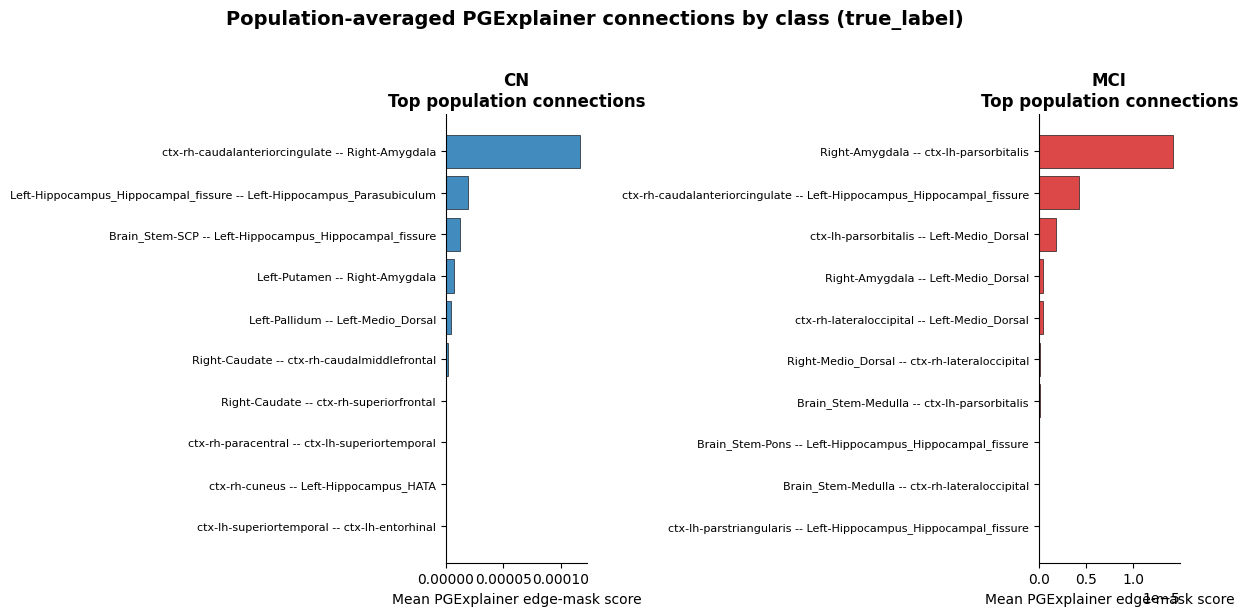

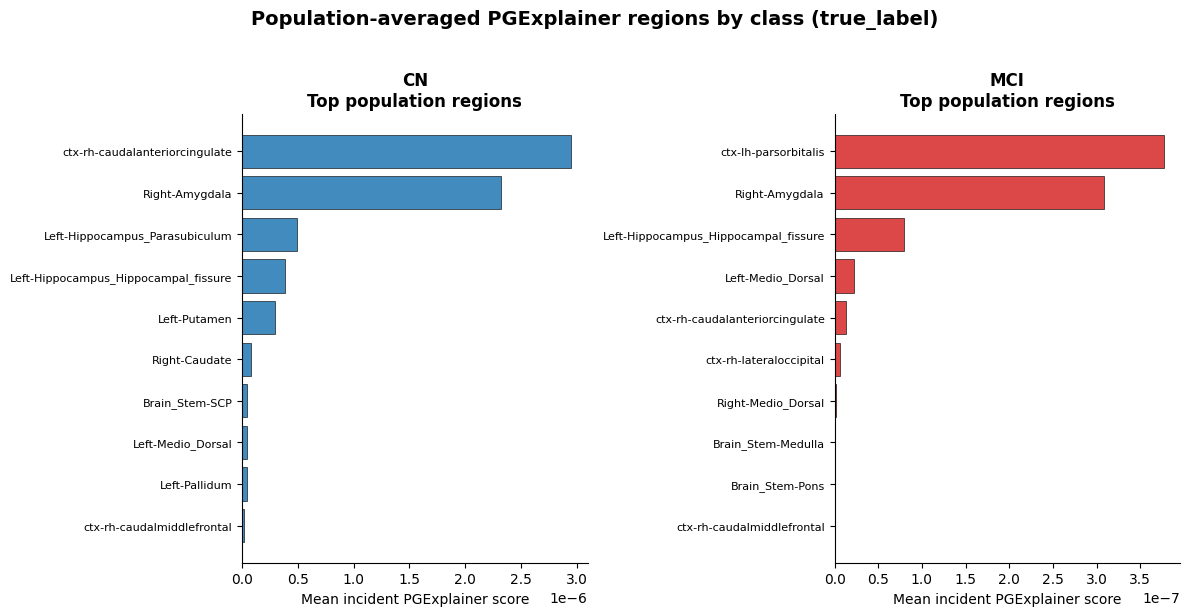

In [16]:
# Per-class PGExplainer plots

CLASS_COLORS = {
    'CN': '#1f77b4',
    'MCI': '#d62728',
}


def plot_population_pg_connections_by_class(summary_df, top_k=10):
    if summary_df.empty:
        print('No per-class connection summary to plot.')
        return

    available_classes = [c for c in ['CN', 'MCI'] if c in summary_df['class_name'].unique()]

    if not available_classes:
        print('No class groups available to plot.')
        return

    fig, axes = plt.subplots(1, len(available_classes), figsize=(6 * len(available_classes), 6))

    if len(available_classes) == 1:
        axes = [axes]

    for ax, class_name in zip(axes, available_classes):
        plot_df = summary_df[summary_df['class_name'] == class_name].head(top_k).copy()
        plot_df['connection'] = plot_df.apply(_connection_label, axis=1)
        plot_df = plot_df.iloc[::-1]

        color = CLASS_COLORS.get(class_name, '#4c72b0')

        ax.barh(
            plot_df['connection'],
            plot_df['mean_pg_score_max'],
            color=color,
            alpha=0.85,
            edgecolor='black',
            linewidth=0.5,
        )

        ax.set_xlabel('Mean PGExplainer edge-mask score')
        ax.set_title(f'{class_name}\nTop population connections', fontsize=12, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle(
        f'Population-averaged PGExplainer connections by class ({CLASS_GROUP_COL})',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


def plot_population_pg_nodes_by_class(summary_df, top_k=10):
    if summary_df.empty:
        print('No per-class node summary to plot.')
        return

    available_classes = [c for c in ['CN', 'MCI'] if c in summary_df['class_name'].unique()]

    if not available_classes:
        print('No class groups available to plot.')
        return

    fig, axes = plt.subplots(1, len(available_classes), figsize=(6 * len(available_classes), 6))

    if len(available_classes) == 1:
        axes = [axes]

    for ax, class_name in zip(axes, available_classes):
        plot_df = summary_df[summary_df['class_name'] == class_name].head(top_k).copy().iloc[::-1]
        color = CLASS_COLORS.get(class_name, '#4c72b0')

        ax.barh(
            plot_df['region'],
            plot_df['mean_incident_pg_score'],
            color=color,
            alpha=0.85,
            edgecolor='black',
            linewidth=0.5,
        )

        ax.set_xlabel('Mean incident PGExplainer score')
        ax.set_title(f'{class_name}\nTop population regions', fontsize=12, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle(
        f'Population-averaged PGExplainer regions by class ({CLASS_GROUP_COL})',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


plot_population_pg_connections_by_class(pg_class_connection_summary_df, top_k=10)
plot_population_pg_nodes_by_class(pg_class_node_summary_df, top_k=10)

In [17]:
# Signed node contribution analysis toward MCI


def get_model_outputs_from_tensors(x, edge_index, edge_attr):
    """
    Returns logits and probabilities for a single graph represented by tensors.
    """
    model.eval()

    batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

    with torch.no_grad():
        logits = model(x, edge_index, edge_attr, batch)
        probs = torch.softmax(logits, dim=-1)

    return logits.detach(), probs.detach()


def ablate_node_for_signed_analysis(g, node_idx, zero_node_features=True, remove_incident_edges=True):
    """
    Creates an ablated version of graph g for signed node analysis.

    zero_node_features=True:
        Sets the selected node's features to zero.

    remove_incident_edges=True:
        Removes all incoming and outgoing edges connected to that node.

    This gives a stricter node-removal style perturbation.
    """
    g = g.to(DEVICE)

    x_ablated = g.x.clone()
    edge_index_ablated = g.edge_index.clone()
    edge_attr_ablated = g.edge_attr.clone() if g.edge_attr is not None else None

    node_idx = int(node_idx)

    if zero_node_features:
        x_ablated[node_idx] = 0.0

    if remove_incident_edges:
        keep_edges = (
            (edge_index_ablated[0] != node_idx) &
            (edge_index_ablated[1] != node_idx)
        )

        edge_index_ablated = edge_index_ablated[:, keep_edges]

        if edge_attr_ablated is not None:
            edge_attr_ablated = edge_attr_ablated[keep_edges]

    return x_ablated, edge_index_ablated, edge_attr_ablated


def signed_node_contribution_table(
    g,
    subject_id=None,
    test_index=None,
    true_label=None,
    pred_label=None,
    prob_MCI_original=None,
    zero_node_features=True,
    remove_incident_edges=True,
):
    """
    Computes signed node contribution toward MCI.

    signed_prob_delta_MCI = original_prob_MCI - ablated_prob_MCI

    Interpretation:
        positive -> node supports MCI probability
        negative -> node suppresses MCI probability / supports CN
    """
    g = g.to(DEVICE)

    full_logits, full_probs = get_model_outputs_from_tensors(
        g.x,
        g.edge_index,
        g.edge_attr,
    )

    full_logit_mci = float(full_logits[0, 1].item())
    full_prob_mci = float(full_probs[0, 1].item())

    rows = []

    for node_idx in range(g.x.size(0)):
        x_ablated, edge_index_ablated, edge_attr_ablated = ablate_node_for_signed_analysis(
            g,
            node_idx=node_idx,
            zero_node_features=zero_node_features,
            remove_incident_edges=remove_incident_edges,
        )

        ablated_logits, ablated_probs = get_model_outputs_from_tensors(
            x_ablated,
            edge_index_ablated,
            edge_attr_ablated,
        )

        ablated_logit_mci = float(ablated_logits[0, 1].item())
        ablated_prob_mci = float(ablated_probs[0, 1].item())

        signed_prob_delta = full_prob_mci - ablated_prob_mci
        signed_logit_delta = full_logit_mci - ablated_logit_mci

        if signed_prob_delta > 0:
            direction = 'supports_MCI'
        elif signed_prob_delta < 0:
            direction = 'supports_CN'
        else:
            direction = 'neutral'

        rows.append({
            'subject_id': subject_id,
            'test_index': test_index,
            'true_label': true_label,
            'pred_label': pred_label,
            'node': int(node_idx),
            'region': node_label(node_idx),
            'original_prob_MCI': full_prob_mci,
            'ablated_prob_MCI': ablated_prob_mci,
            'signed_prob_delta_MCI': float(signed_prob_delta),
            'abs_prob_delta_MCI': float(abs(signed_prob_delta)),
            'original_logit_MCI': full_logit_mci,
            'ablated_logit_MCI': ablated_logit_mci,
            'signed_logit_delta_MCI': float(signed_logit_delta),
            'abs_logit_delta_MCI': float(abs(signed_logit_delta)),
            'direction': direction,
        })

    return (
        pd.DataFrame(rows)
        .sort_values('abs_prob_delta_MCI', ascending=False)
        .reset_index(drop=True)
    )

In [18]:
# Run signed node analysis per class


signed_node_tables = []
signed_node_failures = []

for _, row in predictions_df.iterrows():
    idx = int(row['test_index'])
    subject_id = row['subject_id']
    g = test_graphs[idx].to(DEVICE)

    try:
        signed_df = signed_node_contribution_table(
            g,
            subject_id=subject_id,
            test_index=idx,
            true_label=int(row['true_label']),
            pred_label=int(row['pred_label']),
            prob_MCI_original=float(row['prob_MCI']),
            zero_node_features=True,
            remove_incident_edges=True,
        )

        signed_df['true_class_name'] = signed_df['true_label'].map(CLASS_NAMES)
        signed_df['pred_class_name'] = signed_df['pred_label'].map(CLASS_NAMES)
        signed_node_tables.append(signed_df)

    except Exception as e:
        signed_node_failures.append((subject_id, idx, str(e)))
        print(f'Signed node analysis failed for subject {subject_id}, test_index={idx}: {e}')


all_signed_nodes_df = pd.concat(signed_node_tables, ignore_index=True) if signed_node_tables else pd.DataFrame()

print('Signed node analysis complete.')
print(f'Successful subjects: {all_signed_nodes_df["subject_id"].nunique() if not all_signed_nodes_df.empty else 0}')
print(f'Failures: {len(signed_node_failures)}')

display(all_signed_nodes_df.head(10))

Signed node analysis complete.
Successful subjects: 127
Failures: 0


,subject_id,test_index,true_label,pred_label,node,region,original_prob_MCI,ablated_prob_MCI,signed_prob_delta_MCI,abs_prob_delta_MCI,original_logit_MCI,ablated_logit_MCI,signed_logit_delta_MCI,abs_logit_delta_MCI,direction,true_class_name,pred_class_name
0,OAS30002,0,0,0,5,ctx-rh-rostralmiddlefrontal,0.352914,0.379477,-0.026563,0.026563,-0.332808,-0.297858,-0.034950,0.034950,supports_CN,CN,CN
1,OAS30002,0,0,0,106,Left-Hippocampus_HATA,0.352914,0.375607,-0.022693,0.022693,-0.332808,-0.304386,-0.028422,0.028422,supports_CN,CN,CN
2,OAS30002,0,0,0,0,ctx-rh-lateralorbitofrontal,0.352914,0.370056,-0.017142,0.017142,-0.332808,-0.310148,-0.022660,0.022660,supports_CN,CN,CN
3,OAS30002,0,0,0,77,Left-Hippocampus_Tail,0.352914,0.368792,-0.015879,0.015879,-0.332808,-0.331133,-0.001675,0.001675,supports_CN,CN,CN
4,OAS30002,0,0,0,96,Right-Hippocampus_Parasubiculum,0.352914,0.366611,-0.013698,0.013698,-0.332808,-0.315309,-0.017499,0.017499,supports_CN,CN,CN
5,OAS30002,0,0,0,37,ctx-rh-middletemporal,0.352914,0.366273,-0.013359,0.013359,-0.332808,-0.311258,-0.021550,0.021550,supports_CN,CN,CN
6,OAS30002,0,0,0,42,ctx-lh-parstriangularis,0.352914,0.364399,-0.011485,0.011485,-0.332808,-0.312998,-0.019810,0.019810,supports_CN,CN,CN
7,OAS30002,0,0,0,89,Right-Hippocampus_Hippocampal_fissure,0.352914,0.364234,-0.011320,0.011320,-0.332808,-0.318225,-0.014583,0.014583,supports_CN,CN,CN
8,OAS30002,0,0,0,90,Right-Hippocampus_Tail,0.352914,0.363490,-0.010577,0.010577,-0.332808,-0.319490,-0.013319,0.013319,supports_CN,CN,CN
9,OAS30002,0,0,0,6,ctx-rh-superiorfrontal,0.352914,0.362670,-0.009756,0.009756,-0.332808,-0.317120,-0.015688,0.015688,supports_CN,CN,CN


In [19]:
# Signed node summaries by class


SIGNED_CLASS_GROUP_COL = 'true_class_name'
# Alternative:
# SIGNED_CLASS_GROUP_COL = 'pred_class_name'


def summarize_signed_nodes_by_class(signed_df, class_col='true_class_name'):
    if signed_df.empty:
        return pd.DataFrame()

    return (
        signed_df
        .groupby([class_col, 'node', 'region'], as_index=False)
        .agg(
            mean_signed_prob_delta_MCI=('signed_prob_delta_MCI', 'mean'),
            std_signed_prob_delta_MCI=('signed_prob_delta_MCI', 'std'),
            mean_abs_prob_delta_MCI=('abs_prob_delta_MCI', 'mean'),
            mean_signed_logit_delta_MCI=('signed_logit_delta_MCI', 'mean'),
            mean_abs_logit_delta_MCI=('abs_logit_delta_MCI', 'mean'),
            n_subjects=('subject_id', 'nunique'),
            n_supports_MCI=('direction', lambda x: int((x == 'supports_MCI').sum())),
            n_supports_CN=('direction', lambda x: int((x == 'supports_CN').sum())),
        )
        .assign(
            dominant_direction=lambda df: np.where(
                df['mean_signed_prob_delta_MCI'] > 0,
                'supports_MCI',
                np.where(
                    df['mean_signed_prob_delta_MCI'] < 0,
                    'supports_CN',
                    'neutral'
                )
            )
        )
        .sort_values([class_col, 'mean_abs_prob_delta_MCI'], ascending=[True, False])
        .reset_index(drop=True)
    )


signed_node_class_summary_df = summarize_signed_nodes_by_class(
    all_signed_nodes_df,
    class_col=SIGNED_CLASS_GROUP_COL,
)

print(f'Signed node contribution summary grouped by {SIGNED_CLASS_GROUP_COL}:')
display(signed_node_class_summary_df.groupby(SIGNED_CLASS_GROUP_COL).head(15))


print('Top nodes supporting MCI by class:')
display(
    signed_node_class_summary_df
    .sort_values([SIGNED_CLASS_GROUP_COL, 'mean_signed_prob_delta_MCI'], ascending=[True, False])
    .groupby(SIGNED_CLASS_GROUP_COL)
    .head(10)
)


print('Top nodes supporting CN / opposing MCI by class:')
display(
    signed_node_class_summary_df
    .sort_values([SIGNED_CLASS_GROUP_COL, 'mean_signed_prob_delta_MCI'], ascending=[True, True])
    .groupby(SIGNED_CLASS_GROUP_COL)
    .head(10)
)

Signed node contribution summary grouped by true_class_name:


,true_class_name,node,region,mean_signed_prob_delta_MCI,std_signed_prob_delta_MCI,mean_abs_prob_delta_MCI,mean_signed_logit_delta_MCI,mean_abs_logit_delta_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction
0,CN,24,ctx-rh-posteriorcingulate,-0.001199,0.011656,0.005184,-0.001857,0.008691,105,33,72,supports_CN
1,CN,54,Left-Anterior,0.000530,0.013877,0.005071,0.000566,0.007220,105,31,74,supports_MCI
2,CN,90,Right-Hippocampus_Tail,-0.000945,0.012604,0.004777,-0.002653,0.007668,105,28,77,supports_CN
3,CN,51,ctx-lh-precentral,-0.000654,0.011180,0.004754,-0.001929,0.007195,105,34,71,supports_CN
4,CN,35,ctx-lh-parsorbitalis,0.000105,0.008845,0.004659,-0.000557,0.006953,105,33,72,supports_MCI
5,CN,6,ctx-rh-superiorfrontal,-0.001086,0.009131,0.004628,-0.001776,0.007238,105,27,78,supports_CN
6,CN,20,ctx-rh-fusiform,-0.002678,0.010964,0.004588,-0.004575,0.006696,105,21,84,supports_CN
7,CN,83,Left-Hippocampus,-0.000693,0.009923,0.004582,-0.002022,0.008292,105,34,71,supports_CN
8,CN,3,Right-Caudate,-0.000703,0.009039,0.004574,-0.000858,0.007550,105,24,81,supports_CN
9,CN,89,Right-Hippocampus_Hippocampal_fissure,0.000299,0.008322,0.004467,-0.002619,0.007885,105,34,71,supports_MCI


Top nodes supporting MCI by class:


,true_class_name,node,region,mean_signed_prob_delta_MCI,std_signed_prob_delta_MCI,mean_abs_prob_delta_MCI,mean_signed_logit_delta_MCI,mean_abs_logit_delta_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction
43,CN,105,Left-Hippocampus_Hippocampal_fissure,0.001533,0.013650,0.003516,0.001579,0.004548,105,25,79,supports_MCI
10,CN,102,ctx-lh-superiortemporal,0.001462,0.014905,0.004382,0.001866,0.006469,105,25,79,supports_MCI
18,CN,57,ctx-rh-bankssts,0.001055,0.009245,0.004060,0.001012,0.006380,105,38,67,supports_MCI
53,CN,108,Left-Hippocampus_Fimbria,0.001010,0.009359,0.003395,0.000933,0.005814,105,24,80,supports_MCI
81,CN,104,ctx-lh-transversetemporal,0.000676,0.006964,0.003034,0.000374,0.004064,105,26,78,supports_MCI
36,CN,15,ctx-rh-parsopercularis,0.000661,0.007932,0.003590,-0.000044,0.006731,105,37,68,supports_MCI
19,CN,103,ctx-lh-cuneus,0.000541,0.015090,0.004042,0.000144,0.005043,105,20,83,supports_MCI
1,CN,54,Left-Anterior,0.000530,0.013877,0.005071,0.000566,0.007220,105,31,74,supports_MCI
58,CN,100,ctx-lh-bankssts,0.000511,0.006389,0.003348,-0.000886,0.005297,105,32,73,supports_MCI
9,CN,89,Right-Hippocampus_Hippocampal_fissure,0.000299,0.008322,0.004467,-0.002619,0.007885,105,34,71,supports_MCI


Top nodes supporting CN / opposing MCI by class:


,true_class_name,node,region,mean_signed_prob_delta_MCI,std_signed_prob_delta_MCI,mean_abs_prob_delta_MCI,mean_signed_logit_delta_MCI,mean_abs_logit_delta_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction
6,CN,20,ctx-rh-fusiform,-0.002678,0.010964,0.004588,-0.004575,0.006696,105,21,84,supports_CN
47,CN,2,ctx-rh-medialorbitofrontal,-0.002485,0.008742,0.003461,-0.004033,0.006144,105,21,84,supports_CN
12,CN,94,ctx-lh-frontalpole,-0.002100,0.010027,0.004206,-0.003075,0.006955,105,34,71,supports_CN
54,CN,5,ctx-rh-rostralmiddlefrontal,-0.002038,0.005983,0.003390,-0.002699,0.005223,105,23,82,supports_CN
75,CN,34,Right-VentralDC,-0.002033,0.004875,0.003116,-0.002894,0.005807,105,23,82,supports_CN
25,CN,52,ctx-lh-posteriorcingulate,-0.001937,0.006681,0.003835,-0.002744,0.006753,105,33,72,supports_CN
74,CN,14,Right-Pallidum,-0.001828,0.004745,0.003139,-0.002892,0.005287,105,31,74,supports_CN
77,CN,1,Right-Putamen,-0.001771,0.004961,0.003103,-0.004019,0.005627,105,26,79,supports_CN
87,CN,80,ctx-lh-isthmuscingulate,-0.001737,0.004660,0.002919,-0.002902,0.006006,105,24,81,supports_CN
66,CN,43,Right-Central_Lateral-Lateral_Posterior-Medial...,-0.001671,0.004821,0.003194,-0.003470,0.006294,105,24,81,supports_CN


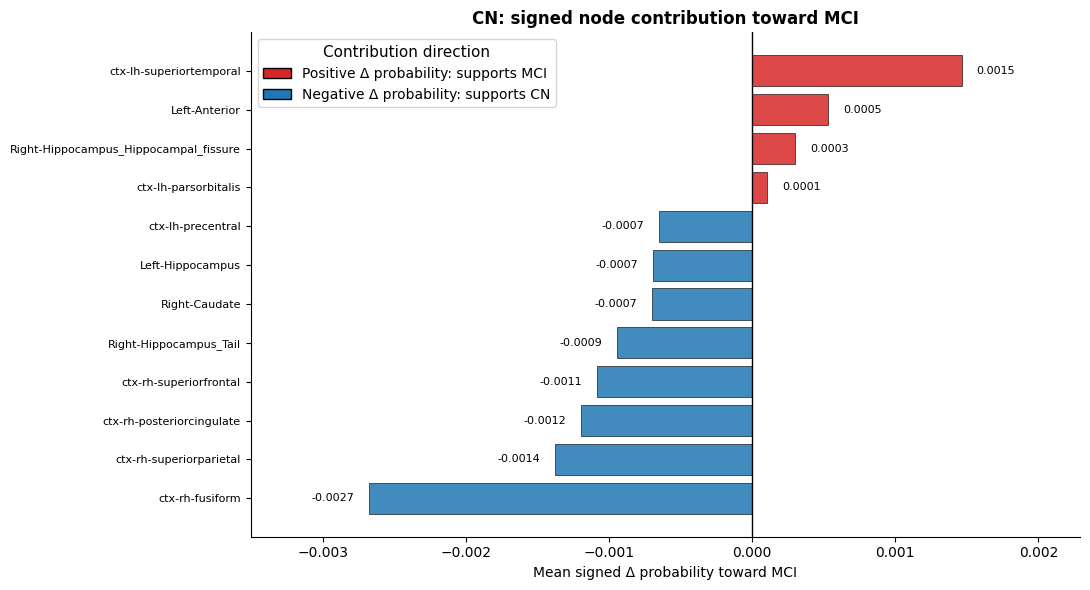

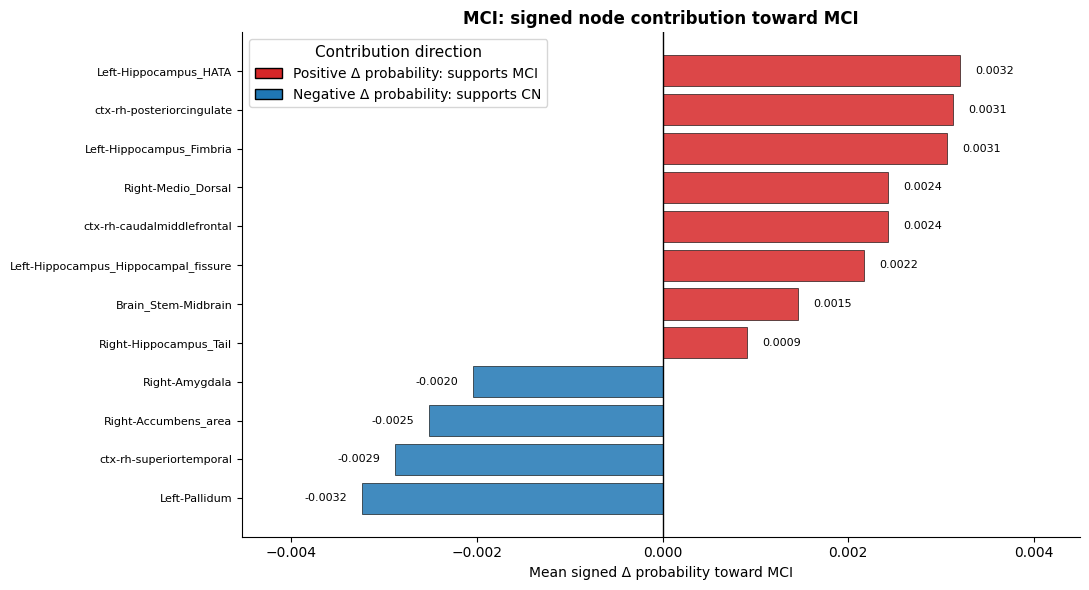

In [20]:
from matplotlib.patches import Patch

# Signed node plots by class

def plot_signed_nodes_by_class(summary_df, class_col='true_class_name', top_k=12):
    if summary_df.empty:
        print('No signed node summary to plot.')
        return

    available_classes = [c for c in ['CN', 'MCI'] if c in summary_df[class_col].unique()]

    if not available_classes:
        print('No class groups available to plot.')
        return

    for class_name in available_classes:
        class_df = summary_df[summary_df[class_col] == class_name].copy()

        # Select nodes with largest absolute signed effect.
        plot_df = (
            class_df
            .sort_values('mean_abs_prob_delta_MCI', ascending=False)
            .head(top_k)
            .sort_values('mean_signed_prob_delta_MCI', ascending=True)
        )

        colors = plot_df['mean_signed_prob_delta_MCI'].apply(
            lambda x: '#d62728' if x > 0 else '#1f77b4'
        )

        fig, ax = plt.subplots(figsize=(11, 6))

        bars = ax.barh(
            plot_df['region'],
            plot_df['mean_signed_prob_delta_MCI'],
            color=colors,
            alpha=0.85,
            edgecolor='black',
            linewidth=0.5,
        )

        ax.axvline(0, color='black', linewidth=1.0)
        ax.set_xlabel('Mean signed Δ probability toward MCI')

        # Cleaner title because explanation is now in the legend
        ax.set_title(
            f'{class_name}: signed node contribution toward MCI',
            fontsize=12,
            fontweight='bold',
        )

        # Larger legend / color key
        legend_elements = [
            Patch(facecolor='#d62728', edgecolor='black', label='Positive Δ probability: supports MCI'),
            Patch(facecolor='#1f77b4', edgecolor='black', label='Negative Δ probability: supports CN'),
        ]

        ax.legend(
            handles=legend_elements,
            loc='best',
            frameon=True,
            fontsize=10,
            title='Contribution direction',
            title_fontsize=11,
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)

        # Dynamic x-axis padding so labels do not overlap or get cut off
        values = plot_df['mean_signed_prob_delta_MCI']
        x_min = values.min()
        x_max = values.max()
        x_range = x_max - x_min if x_max != x_min else max(abs(x_max), 1e-3)

        padding = 0.20 * x_range
        ax.set_xlim(x_min - padding, x_max + padding)

        label_offset = 0.025 * x_range

        for bar, value in zip(bars, values):
            x_pos = bar.get_width()

            if value >= 0:
                label_x = x_pos + label_offset
                ha = 'left'
            else:
                label_x = x_pos - label_offset
                ha = 'right'

            ax.text(
                label_x,
                bar.get_y() + bar.get_height() / 2,
                f'{value:.4f}',
                va='center',
                ha=ha,
                fontsize=8,
                clip_on=False,
            )

        plt.tight_layout()
        plt.show()


plot_signed_nodes_by_class(
    signed_node_class_summary_df,
    class_col=SIGNED_CLASS_GROUP_COL,
    top_k=12,
)

###Node importance with signed contribution

In [21]:
# ============================================================
# Optional: combine PGExplainer node importance with signed direction
# Append after Cell 6
# ============================================================

def combine_pg_importance_with_signed_direction(
    pg_node_summary_df,
    signed_summary_df,
    pg_class_col='class_name',
    signed_class_col='true_class_name',
):
    if pg_node_summary_df.empty or signed_summary_df.empty:
        print('One of the input summaries is empty.')
        return pd.DataFrame()

    combined = pg_node_summary_df.merge(
        signed_summary_df,
        left_on=[pg_class_col, 'node', 'region'],
        right_on=[signed_class_col, 'node', 'region'],
        how='inner',
        suffixes=('_pg', '_signed'),
    )

    combined['pg_weighted_signed_prob_delta_MCI'] = (
        combined['mean_incident_pg_score'] *
        combined['mean_signed_prob_delta_MCI']
    )

    combined['pg_weighted_abs_signed_prob_delta_MCI'] = (
        combined['mean_incident_pg_score'] *
        combined['mean_abs_prob_delta_MCI']
    )

    return (
        combined
        .sort_values(
            [pg_class_col, 'pg_weighted_abs_signed_prob_delta_MCI'],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )


pg_signed_node_combined_df = combine_pg_importance_with_signed_direction(
    pg_class_node_summary_df,
    signed_node_class_summary_df,
    pg_class_col='class_name',
    signed_class_col=SIGNED_CLASS_GROUP_COL,
)

print('Combined PGExplainer importance + signed node direction:')
display(pg_signed_node_combined_df.groupby('class_name').head(15))


print('Most PG-important nodes with positive signed contribution toward MCI:')
display(
    pg_signed_node_combined_df
    .sort_values(['class_name', 'pg_weighted_signed_prob_delta_MCI'], ascending=[True, False])
    .groupby('class_name')
    .head(10)
)


print('Most PG-important nodes with negative signed contribution toward MCI:')
display(
    pg_signed_node_combined_df
    .sort_values(['class_name', 'pg_weighted_signed_prob_delta_MCI'], ascending=[True, True])
    .groupby('class_name')
    .head(10)
)

Combined PGExplainer importance + signed node direction:


,class_name,node,region,mean_incident_pg_score,max_incident_pg_score,n_subjects_pg,true_class_name,mean_signed_prob_delta_MCI,std_signed_prob_delta_MCI,mean_abs_prob_delta_MCI,mean_signed_logit_delta_MCI,mean_abs_logit_delta_MCI,n_subjects_signed,n_supports_MCI,n_supports_CN,dominant_direction,pg_weighted_signed_prob_delta_MCI,pg_weighted_abs_signed_prob_delta_MCI
0,CN,13,ctx-rh-caudalanteriorcingulate,2.949125e-06,7.122076e-03,105,CN,-0.001342,0.006094,0.003701,-0.002320,0.006613,105,28,77,supports_CN,-3.958060e-09,1.091604e-08
1,CN,33,Right-Amygdala,2.320516e-06,7.122076e-03,105,CN,-0.000314,0.004768,0.002799,-0.002059,0.004887,105,38,67,supports_CN,-7.297239e-10,6.494687e-09
2,CN,105,Left-Hippocampus_Hippocampal_fissure,3.847841e-07,5.950669e-04,103,CN,0.001533,0.013650,0.003516,0.001579,0.004548,105,25,79,supports_MCI,5.898245e-10,1.352969e-09
3,CN,27,Left-Putamen,2.933307e-07,4.311945e-04,105,CN,-0.000453,0.006155,0.003350,-0.001564,0.006567,105,29,76,supports_CN,-1.329339e-10,9.826169e-10
4,CN,109,Left-Hippocampus_Parasubiculum,4.915606e-07,5.950669e-04,101,CN,-0.000323,0.003222,0.001600,-0.000757,0.003229,105,22,81,supports_CN,-1.587879e-10,7.864193e-10
5,CN,3,Right-Caudate,7.986501e-08,9.682967e-05,105,CN,-0.000703,0.009039,0.004574,-0.000858,0.007550,105,24,81,supports_CN,-5.610685e-11,3.652714e-10
6,CN,84,Left-Medio_Dorsal,4.359647e-08,2.304714e-04,105,CN,-0.001387,0.007555,0.003517,-0.001785,0.006308,105,30,75,supports_CN,-6.046748e-11,1.533091e-10
7,CN,47,Left-Pallidum,4.008202e-08,2.304714e-04,105,CN,-0.001609,0.006063,0.003486,-0.003218,0.006076,105,26,79,supports_CN,-6.450944e-11,1.397279e-10
8,CN,59,Brain_Stem-SCP,4.502239e-08,2.361090e-04,105,CN,-0.000908,0.004952,0.002780,-0.002080,0.004899,105,32,73,supports_CN,-4.088413e-11,1.251742e-10
9,CN,36,ctx-rh-caudalmiddlefrontal,1.418817e-08,9.682967e-05,105,CN,-0.000628,0.007798,0.003565,-0.000873,0.006140,105,30,75,supports_CN,-8.915278e-12,5.057968e-11


Most PG-important nodes with positive signed contribution toward MCI:


,class_name,node,region,mean_incident_pg_score,max_incident_pg_score,n_subjects_pg,true_class_name,mean_signed_prob_delta_MCI,std_signed_prob_delta_MCI,mean_abs_prob_delta_MCI,mean_signed_logit_delta_MCI,mean_abs_logit_delta_MCI,n_subjects_signed,n_supports_MCI,n_supports_CN,dominant_direction,pg_weighted_signed_prob_delta_MCI,pg_weighted_abs_signed_prob_delta_MCI
2,CN,105,Left-Hippocampus_Hippocampal_fissure,3.847841e-07,5.950669e-04,103,CN,0.001533,0.013650,0.003516,0.001579,0.004548,105,25,79,supports_MCI,5.898245e-10,1.352969e-09
11,CN,102,ctx-lh-superiortemporal,1.243422e-09,3.223863e-06,103,CN,0.001462,0.014905,0.004382,0.001866,0.006469,105,25,79,supports_MCI,1.818461e-12,5.448252e-12
17,CN,108,Left-Hippocampus_Fimbria,2.127818e-10,2.586430e-07,103,CN,0.001010,0.009359,0.003395,0.000933,0.005814,105,24,80,supports_MCI,2.149424e-13,7.224425e-13
15,CN,54,Left-Anterior,2.077380e-10,1.347133e-06,105,CN,0.000530,0.013877,0.005071,0.000566,0.007220,105,31,74,supports_MCI,1.100724e-13,1.053452e-12
20,CN,96,Right-Hippocampus_Parasubiculum,1.068105e-10,2.767864e-07,104,CN,0.000081,0.010172,0.004124,-0.000301,0.006212,105,33,72,supports_MCI,8.691352e-15,4.404750e-13
47,CN,103,ctx-lh-cuneus,9.349209e-12,9.492019e-09,103,CN,0.000541,0.015090,0.004042,0.000144,0.005043,105,20,83,supports_MCI,5.061325e-15,3.778832e-14
46,CN,99,ctx-lh-parahippocampal,1.375331e-11,2.685890e-08,103,CN,0.000126,0.010824,0.003832,-0.000707,0.006368,105,33,72,supports_MCI,1.728833e-15,5.270395e-14
69,CN,104,ctx-lh-transversetemporal,2.010669e-12,1.667964e-09,103,CN,0.000676,0.006964,0.003034,0.000374,0.004064,105,26,78,supports_MCI,1.359110e-15,6.100854e-15
71,CN,100,ctx-lh-bankssts,1.265215e-12,1.938111e-09,103,CN,0.000511,0.006389,0.003348,-0.000886,0.005297,105,32,73,supports_MCI,6.467656e-16,4.236530e-15
48,CN,35,ctx-lh-parsorbitalis,5.832571e-12,5.172884e-08,105,CN,0.000105,0.008845,0.004659,-0.000557,0.006953,105,33,72,supports_MCI,6.145694e-16,2.717519e-14


Most PG-important nodes with negative signed contribution toward MCI:


,class_name,node,region,mean_incident_pg_score,max_incident_pg_score,n_subjects_pg,true_class_name,mean_signed_prob_delta_MCI,std_signed_prob_delta_MCI,mean_abs_prob_delta_MCI,mean_signed_logit_delta_MCI,mean_abs_logit_delta_MCI,n_subjects_signed,n_supports_MCI,n_supports_CN,dominant_direction,pg_weighted_signed_prob_delta_MCI,pg_weighted_abs_signed_prob_delta_MCI
0,CN,13,ctx-rh-caudalanteriorcingulate,2.949125e-06,7.122076e-03,105,CN,-0.001342,0.006094,0.003701,-0.002320,0.006613,105,28,77,supports_CN,-3.958060e-09,1.091604e-08
1,CN,33,Right-Amygdala,2.320516e-06,7.122076e-03,105,CN,-0.000314,0.004768,0.002799,-0.002059,0.004887,105,38,67,supports_CN,-7.297239e-10,6.494687e-09
4,CN,109,Left-Hippocampus_Parasubiculum,4.915606e-07,5.950669e-04,101,CN,-0.000323,0.003222,0.001600,-0.000757,0.003229,105,22,81,supports_CN,-1.587879e-10,7.864193e-10
3,CN,27,Left-Putamen,2.933307e-07,4.311945e-04,105,CN,-0.000453,0.006155,0.003350,-0.001564,0.006567,105,29,76,supports_CN,-1.329339e-10,9.826169e-10
7,CN,47,Left-Pallidum,4.008202e-08,2.304714e-04,105,CN,-0.001609,0.006063,0.003486,-0.003218,0.006076,105,26,79,supports_CN,-6.450944e-11,1.397279e-10
6,CN,84,Left-Medio_Dorsal,4.359647e-08,2.304714e-04,105,CN,-0.001387,0.007555,0.003517,-0.001785,0.006308,105,30,75,supports_CN,-6.046748e-11,1.533091e-10
5,CN,3,Right-Caudate,7.986501e-08,9.682967e-05,105,CN,-0.000703,0.009039,0.004574,-0.000858,0.007550,105,24,81,supports_CN,-5.610685e-11,3.652714e-10
8,CN,59,Brain_Stem-SCP,4.502239e-08,2.361090e-04,105,CN,-0.000908,0.004952,0.002780,-0.002080,0.004899,105,32,73,supports_CN,-4.088413e-11,1.251742e-10
10,CN,6,ctx-rh-superiorfrontal,8.397983e-09,2.821666e-05,105,CN,-0.001086,0.009131,0.004628,-0.001776,0.007238,105,27,78,supports_CN,-9.116206e-12,3.886958e-11
9,CN,36,ctx-rh-caudalmiddlefrontal,1.418817e-08,9.682967e-05,105,CN,-0.000628,0.007798,0.003565,-0.000873,0.006140,105,30,75,supports_CN,-8.915278e-12,5.057968e-11


### Interpretation note

PGExplainer explains the prediction through connection importance. A high score means the learned edge mask retained that connection as important for the NNConv model output for the selected target class.